# Per-view ratiometric analysis pipeline

This script performs cell segmentation and ratiometric signal extraction from two-photon datasets acquired with alternating excitation wavelengths (800 nm and 920 nm).

Before running this pipeline, the dataset must be reorganized using the preprocessing scripts. (file renaming and wavelength pairing). After those steps, each view should contain paired TIFF stacks named with the excitation prefix (e.g. `800_ch2_Zxxx.tif` and `920_ch2_Zxxx.tif`).

Given this standardized structure, the present script runs the full analysis workflow. It segments individual cells in each channel, links cells across the Z-stack, matches corresponding cells between the 800 nm and 920 nm images, performs background correction and quality filtering, and computes the final excitation ratio for each cell. Intermediate results and quality-control outputs are saved at each step of the pipeline.

We want to remind that the workflow is designed for ratiometric imaging datasets in which the same fluorescent reporter is measured under two excitation wavelengths while emission is collected through a single detection channel.

## Installation

Required packages can be installed with:

```bash
pip install numpy scipy scikit-image opencv-python tifffile matplotlib torch segmentation-models-pytorch ipywidgets trackpy

In [1]:
import os
import json
import glob
import re
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import torch
from IPython.display import display
from ipywidgets import IntSlider, interact
import ipywidgets as widgets
from scipy import ndimage as ndi
from segmentation_models_pytorch import Unet
from skimage import measure
from skimage.feature import peak_local_max
from skimage.morphology import remove_small_objects
from skimage.segmentation import watershed
from pathlib import Path

## Load datasets

Specify the directory of the `view` to be analyzed (the folder containing the paired `800_` and `920_` TIFF stacks generated in the preprocessing step).  

When the script is executed, the dataset in this directory is loaded and a `results` folder is automatically created in the same location. This directory contains all outputs generated by the pipeline, organized into subfolders corresponding to each processing step (quality control, segmentation, tracking, cell matching, filtering, and final ratiometric analysis).

In [3]:
# -------- Path --------
VIEW_DIR = "./example_images/view1" #THIS PATH SHOULD BE CHANGED TO YOUR LOCAL PATH

# -------- Result folder --------   
DBG = os.path.join(VIEW_DIR, "results")
S0   = os.path.join(DBG, "S0_discovery")
S11_8 = os.path.join(DBG, "S1_NN_seg_800")
S11_9 = os.path.join(DBG, "S1_NN_seg_920")
S12_8 = os.path.join(DBG, "S1_seg_800")
S12_9 = os.path.join(DBG, "S1_seg_920")
S2_8 = os.path.join(DBG, "S2_tracks_800")
S2_9 = os.path.join(DBG, "S2_tracks_920")
S3 = os.path.join(DBG, "S3_mapping_results")
S4 = os.path.join(DBG, "S4_illumination_correction")
S5_9 = os.path.join(DBG, "S5_backg_subtraction_800")
S5_8  = os.path.join(DBG, "S5_backg_subtraction_920")
S6  = os.path.join(DBG, "S6_size_ratio_dropout")
S7  = os.path.join(DBG, "S7_final_output")


for d in [DBG,S0,S11_8,S11_9,S12_8,S12_9,S2_8,S2_9,S3,S4,S4,S5_8, S5_9, S6, S7]:
    os.makedirs(d, exist_ok=True)

## S0 - visualize

 Loads the paired 800 nm and 920 nm Z-stacks from the selected `view` directory, verifies that both image series are present, and records the detected slice information. An interactive viewer is used to inspect the two stacks side by side across Z as an initial quality-control step before segmentation.

In [ ]:
from common_functions.data_utils import load_stack_sorted

print("S0: Discovering Z-stacks…")
stack800, z800, f800 = load_stack_sorted(VIEW_DIR, "800_")
stack920, z920, f920 = load_stack_sorted(VIEW_DIR, "920_")

meta = {
    "view_dir": VIEW_DIR,
    "n_800": len(stack800),
    "n_920": len(stack920),
    "Z_800": z800,
    "Z_920": z920,
    "first_800": f800[:3],
    "first_920": f920[:3]
}
with open(os.path.join(S0, "discovery.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"  800 nm: {len(stack800)} slices | Zs: {z800}")
print(f"  920 nm: {len(stack920)} slices | Zs: {z920}")

assert len(stack800) > 0, "No 800_*Z*.tif found."
assert len(stack920) > 0, "No 920_*Z*.tif found."
assert stack800[0].ndim == 2 and stack920[0].ndim == 2, "Expect 2D slices."

In [5]:
from common_functions.data_utils import browse_stacks

interact(
    lambda z800_idx, z920_idx: browse_stacks(stack800, z800, stack920, z920, z800_idx, z920_idx),
    z800_idx=IntSlider(min=0, max=len(stack800)-1, step=1, value=0, description="Z (800)"),
    z920_idx=IntSlider(min=0, max=len(stack920)-1, step=1, value=0, description="Z (920)")
);


interactive(children=(IntSlider(value=0, description='Z (800)', max=12), IntSlider(value=0, description='Z (92…

## S1.1 – Neural-network segmentation

Runs a pretrained neural-network model independently on the 800 nm and 920 nm Z-stacks to generate initial cell segmentation masks for each slice. The predicted binary masks are refined into individual cell instances ( by watershead) and saved as per-slice label maps and mask files. An interactive viewer can then be used to inspect the raw image, binary mask, and final instance segmentation across Z for quality control.

The pipeline includes a pretrained model, but users can also provide their own trained model by specifying the path to a compatible `.pth` file when running the segmentation step. Code for training a new model, including examples designed for low signal-to-noise ratio (SNR) images, is provided in the same GitHub repository.

In [6]:
from S1_NN_segmentation.neuralnetwork_segmentation import run_S11_nn, view_S11_nn_results

MODEL_PATH = Path.cwd() / "NN_model" / "NN_pretrained_model.pth"

In [7]:
run_S11_nn("800", stack800, z800, stack920, z920, S11_8, S11_9, MODEL_PATH)
view_S11_nn_results("800", stack800, z800, stack920, z920, S11_8, S11_9)

S11: Running NN segmentation for channel 800...
Using device: mps
Loading model: /Users/davidesperi/Desktop/ExRai_ratio_video_analysis_GIT_noWARNINGS/S2_per_view_analysis/NN_model/NN_pretrained_model.pth
[S11_800] Z001 → 14 cells
[S11_800] Z002 → 24 cells
[S11_800] Z003 → 28 cells
[S11_800] Z004 → 36 cells
[S11_800] Z005 → 43 cells
[S11_800] Z006 → 47 cells
[S11_800] Z007 → 35 cells
[S11_800] Z008 → 33 cells
[S11_800] Z009 → 35 cells
[S11_800] Z010 → 29 cells
[S11_800] Z011 → 26 cells
[S11_800] Z012 → 26 cells
[S11_800] Z013 → 30 cells
✅ S11 NN segmentation complete for channel 800.


interactive(children=(IntSlider(value=0, description='800 nm Z-index:', max=12), Output()), _dom_classes=('wid…

In [8]:
run_S11_nn("920", stack800, z800, stack920, z920, S11_8, S11_9, MODEL_PATH)
view_S11_nn_results("920", stack800, z800, stack920, z920, S11_8, S11_9)

S11: Running NN segmentation for channel 920...
Using device: mps
Loading model: /Users/davidesperi/Desktop/ExRai_ratio_video_analysis_GIT_noWARNINGS/S2_per_view_analysis/NN_model/NN_pretrained_model.pth
[S11_920] Z001 → 2 cells
[S11_920] Z002 → 4 cells
[S11_920] Z003 → 6 cells
[S11_920] Z004 → 9 cells
[S11_920] Z005 → 10 cells
[S11_920] Z006 → 9 cells
[S11_920] Z007 → 12 cells
[S11_920] Z008 → 15 cells
[S11_920] Z009 → 17 cells
[S11_920] Z010 → 6 cells
[S11_920] Z011 → 6 cells
[S11_920] Z012 → 3 cells
[S11_920] Z013 → 6 cells
✅ S11 NN segmentation complete for channel 920.


interactive(children=(IntSlider(value=0, description='920 nm Z-index:', max=12), Output()), _dom_classes=('wid…

## S1.2 – Cell segmentation by region growing

Performs interactive cell segmentation on each Z-slice using manual seeding combined with adaptive region growing. The interface displays three panels to assist segmentation:

- **Left:** raw image (contrast enhanced) to help visualize cell boundaries.  
- **Center:** neural-network segmentation results used as a reference for potential cell locations.  
- **Right:** the current region-growing segmentation showing labeled cell instances generated from user interactions.

To segment a cell, click near the **center of the cell body**. The algorithm initializes a region-growing procedure from the selected seed and produces an individual cell mask.

### Interaction controls

- **Left click:** add a seed to segment a new cell or interact with an existing mask.  
- **Right click:** undo the last region-growing operation.  
- **q / b:** move forward or backward through Z-slices.  
- **n / r:** toggle visualization between neural-network reference and region-growing comparison.  
- **[ / ]:** decrease or increase the overlap threshold used to compare NN and region-growing results.  
- **a:** accept the neural-network segmentation for the selected region.  
- **m:** merge two masks into a single cell.  
- **c:** clear the current segmentation.  
- **s:** save the current slice segmentation.  
- **ESC:** exit the interface.

### Watershed splitting

If a region-growing mask contains **two adjacent cells**, the region can be split using watershed refinement.  
1. **First click:** select the existing mask containing the merged cells.  
2. **Second click:** place a second marker inside the same mask on the second cell.  

These two clicks define the peaks used as watershed markers. The algorithm computes a distance transform within the selected mask and separates the region into two independent cell instances.

### Mask merging

If a single cell is not gettingin detected as unique masks (for example due to a dim center or nucleus), the masks can be merged:

1. Press **`m`** to activate merge mode.  
2. **Left-click the two masks** that should be considered the same cell.  

The selected regions are then combined into a single instance mask.

### Practical notes

- **Click near the center of each cell** for the most stable segmentation.  
- If the region grows too much or behaves unexpectedly, **undo (`right click`) and repeat the seed placement**.  
- **Always save (`s`) before moving to another slice**, otherwise segmentation progress will be lost.  
- Watershed splitting may require several attempts depending on seed placement and local contrast.

The final edited instance masks are saved for each Z-slice and used in downstream steps for cell tracking, inter-channel matching, and ratiometric analysis.

In [9]:
from S1_regiongrow.run_S1_final import run_S1_regiongrow

In [10]:
run_S1_regiongrow("800", VIEW_DIR, S12_8, S12_9, S11_8, S11_9)

[Z001] RR (frac=0.88 ≥ 0.80) | overlap=0.88
[Z001] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z001] NN (frac=0.75 < 0.80, favor NN) | overlap=0.75
[Z001] RR (frac=0.94 ≥ 0.80) | overlap=0.94
[Z001] RR (frac=0.99 ≥ 0.80) | overlap=0.99
[Z001] RR (frac=0.90 ≥ 0.80) | overlap=0.90
[Z001] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Undo] Z001 last region 7 removed.
[Z001] RR (frac=0.99 ≥ 0.80) | overlap=0.99
[Z001] RR (no NN at seed) | overlap=0.00
[Z001] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z001] RR (no NN at seed) | overlap=0.00
[Z001] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z001] RR (no NN at seed) | overlap=0.00
[Undo] Z001 last region 12 removed.
[Saved] Z001 | cells=11
[Z002] RR (frac=0.97 ≥ 0.80) | overlap=0.97
[Z002] RR (frac=0.96 ≥ 0.80) | overlap=0.96
[Z002] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z002] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z002] RR (frac=0.92 ≥ 0.80) | overlap=0.92
[Z002] RR (no NN at seed) | overlap=0.00
[Z002] RR (frac=0.82 ≥ 0.80) | overlap=0.82
[Z002] RR (frac=0.92 ≥ 0.80

In [11]:
run_S1_regiongrow("920", VIEW_DIR, S12_8, S12_9, S11_8, S11_9)

[Z001] RR (no NN at seed) | overlap=0.00
[Z001] RR (no NN at seed) | overlap=0.00
[Z001] RR (no NN at seed) | overlap=0.00
[Z001] RR (no NN at seed) | overlap=0.00
[Saved] Z001 | cells=4
[Z002] RR (frac=0.85 ≥ 0.80) | overlap=0.85
[Z002] RR (frac=0.85 ≥ 0.80) | overlap=0.85
[Z002] RR (frac=1.00 ≥ 0.80) | overlap=1.00
[Z002] RR (frac=0.83 ≥ 0.80) | overlap=0.83
[Z002] RR (no NN at seed) | overlap=0.00
[Saved] Z002 | cells=5
[Z003] RR (no NN at seed) | overlap=0.00
[Z003] RR (no NN at seed) | overlap=0.00
[Z003] NN (frac=0.44 < 0.80, favor NN) | overlap=0.44
[Z003] RR (no NN at seed) | overlap=0.00
[Z003] RR (no NN at seed) | overlap=0.00
[Z003] RR (no NN at seed) | overlap=0.00
[Z003] NN (frac=0.48 < 0.80, favor NN) | overlap=0.48
[Saved] Z003 | cells=7
[Z004] RR (no NN at seed) | overlap=0.00
[Z004] RR (frac=0.97 ≥ 0.80) | overlap=0.97
[Z004] RR (no NN at seed) | overlap=0.00
[Z004] NN (frac=0.72 < 0.80, favor NN) | overlap=0.72
[Z004] NN (frac=0.78 < 0.80, favor NN) | overlap=0.78
[Z0

## S2 – Cell tracking across the Z-stack

Links segmented cells across Z-slices to reconstruct the same cell through the stack. To compensate for slice-to-slice drift or small rotations, the user first defines three anchor points per slice. These anchors are used to estimate a geometric alignment between slices before tracking the segmented cells.

The interface displays the raw image together with the segmentation masks, and the user selects three anchor points on each Z-plane. These anchors define a transformation that aligns all slices to a common reference frame. After alignment, cell centroids are linked across adjacent slices to generate Z-tracks for each cell.

### Anchor selection strategies

Two strategies can be used depending on the stability of the Z-stack.

**Low motion / stable slices**  
If the stack is stable and the field of view does not move significantly between slices, select three fixed points near the borders of the image (for example near the corners). Use approximately the same positions in every slice to define the alignment.

**High motion / image drift**  
If the image shifts or rotates across slices, select three distinct cells or anatomical features that can be followed through the Z-stack. Choose points that are well separated across the image to improve alignment stability.

### Practical notes

- Always select **three anchors per slice** before moving to the next slice.  
- Anchors should be **well separated across the field of view** to provide a stable alignment transformation.  

### Resetting anchor selection

If a mistake is made during anchor placement or the anchors need to be redefined, remove the previously generated output files and repeat the process.

Delete **all files inside the output folder** (for example `.json`, `.csv`, `.tif` files), but **do not delete the folder itself** ( If done by mistake rerun the load dataset step).
Once the files are removed, anchor collection, alignment, and tracking can be executed again.

In [12]:
from S2_tracking.run_S2 import run_S2_manual_anchor_3pts

In [13]:
run_S2_manual_anchor_3pts('800', VIEW_DIR, S12_8, S12_9, S2_8, S2_9)

Frame 13: 16 trajectories present.
✅ Exported 71 tracks (mask stacks + per-Z masks + index CSV).


In [15]:
run_S2_manual_anchor_3pts('920', VIEW_DIR, S12_8, S12_9, S2_8, S2_9)

Frame 13: 2 trajectories present.
✅ Exported 39 tracks (mask stacks + per-Z masks + index CSV).


## S3 – Cell mapping between excitation channels

Identifies corresponding cells between the 800 nm and 920 nm segmentations using centroid positions. The interface allows the user to explore candidate matches between the two channels and refine the final correspondence interactively.

The display contains three panels:

- **Left:** centroid positions detected in the two channels for the selected Z-plane.  
- **Center:** the raw 800 nm image for the selected slice.  
- **Right:** the raw 920 nm image for the selected slice

The sliders allow the user to select the Z-slices to compare, define the maximum centroid distance allowed for pairing, and apply lateral offsets between the two channels. Two matching strategies are available: **Hungarian** (global optimal assignment) and **Nearest** (local nearest-neighbor matching).

### Mapping selection

For each segmented cell detected in the **800 nm channel**, a drop-down menu lists the possible matches detected between **800 nm channel** and the **920 nm channel**.

Each entry in the list is displayed as:

`920_index (#N)`

- **920_index:** the index of the cell in the 920 nm segmentation proposed as the match.  
- **#N:** the number of times this pair of cells was matched while scanning across the entire Z-stack.

During this step, each cell detected in the **800 nm channel** in a given Z-plane is compared with detections across all slices in the stack. Because the same cell can be detected in multiple slices, the number of matches (**#N**) can be larger than the Z stack size. Higher values therefore indicate a **more consistent pairing across the Z-stack**, which typically corresponds to the correct match.

If a candidate pairing appears incorrect (for example when matches occur only in a few slices or are visually inconsistent), the user can select **“None”** from the drop-down list to exclude that cell from the mapping.

### Practical notes

- Choose Z-planes containing clearly segmented cells in both channels.  
- Use **Offset X** and **Offset Y** if the two channels appear laterally shifted.  
- Adjust **maximum distance** to restrict matching to spatially plausible cell pairs.  
- The **Hungarian** method performs global one-to-one assignment, whereas **Nearest** performs local nearest-neighbor pairing.

The resulting mapping defines the correspondence between cells imaged at the two excitation wavelengths and is used in subsequent filtering and ratiometric analysis steps.

In [ ]:
from S3_mapping.run_S3 import run_S3_mapping
from common_functions.data_utils import load_raw_map

raw800_map, z800_list, _ = load_raw_map("800", VIEW_DIR)
raw920_map, z920_list, _ = load_raw_map("920", VIEW_DIR)

widgets.interact(
    lambda z800, z920, max_dist, offset_x, offset_y, method:
        run_S3_mapping(z800, z920, max_dist, offset_x, offset_y, method, VIEW_DIR, S2_8, S2_9),
    z800=widgets.IntSlider(min=min(z800_list), max=max(z800_list), step=1, value=z800_list[0]),
    z920=widgets.IntSlider(min=min(z920_list), max=max(z920_list), step=1, value=z920_list[0]),
    max_dist=widgets.IntSlider(min=5, max=500, step=5, value=15),
    offset_x=widgets.FloatSlider(min=-200, max=100, step=1, value=0, description="Offset X (px)"),
    offset_y=widgets.FloatSlider(min=-200, max=100, step=1, value=0, description="Offset Y (px)"),
    method=widgets.RadioButtons(options=["Hungarian", "Nearest"], value="Hungarian", description="Method")
)


interactive(children=(IntSlider(value=1, description='z800', max=13, min=1), IntSlider(value=1, description='z…

<function __main__.<lambda>(z800, z920, max_dist, offset_x, offset_y, method)>

## S4 – Illumination drop-out filtering

This step identifies regions of the image that are sufficiently illuminated and excludes cells located in areas where the signal is unreliable due to illumination fall-off or vignetting. Because two-photon imaging often produces non-uniform excitation across the field of view, cells located in poorly illuminated regions may show artificially reduced intensity and bias ratiometric measurements.

The interface displays the estimated illumination mask for both excitation channels:

- **Left:** 800 nm image with the computed illumination mask overlay.  
- **Right:** 920 nm image with the corresponding illumination mask.

The dark red region indicates the **area considered sufficiently illuminated**, while regions outside this mask are excluded from analysis.

### Illumination mask estimation

The illumination mask is estimated automatically from the image data. The brightest Z-slices in the stack are combined to approximate the underlying illumination field, and the resulting image is strongly smoothed to remove cell-scale structures while preserving large-scale intensity gradients. The smoothed image is then normalized and thresholded to define the region where illumination remains above a user-defined fraction of the peak intensity.

This procedure isolates the central region of the field of view where excitation and detection are most stable.

### Interactive parameters

The user can interactively adjust several parameters:

- **Z800 / Z920:** select the Z-slice used for visualization.  
- **Keep ≥ 800:** threshold defining the minimum illumination fraction retained for the 800 nm channel.  
- **Keep ≥ 920:** threshold defining the minimum illumination fraction retained for the 920 nm channel.

Adjusting these thresholds changes the size of the accepted illumination region.

### Practical note

If the threshold is set too low, the illumination mask may expand to include the entire field of view. In this case the entire image will appear non included (white - but is still continue to be no excluded regions), meaning that no regions are excluded. While this configuration is possible, it is generally unlikely to be appropriate and should only occur when illumination is extremely uniform across the field of view.

Cells are retained for further analysis only if their centroid falls within the illuminated region in **both excitation channels**. Once the mask boundaries are visually verified, press **“Save mask”** to store the illumination mask used for filtering in subsequent steps of the pipeline.

In [ ]:
from S4_illumination_drop_out.run_S4 import run_S4_illumination

run_S4_illumination(VIEW_DIR, S2_8, S2_9, S3, S4)

Output()

## S5 – Local background subtraction

Measures fluorescence intensity for each segmented cell after correcting for local background signal. Background subtraction is performed independently for the 800 nm and 920 nm channels and is used to reduce contributions from diffuse tissue fluorescence, detector offset, and local intensity bias surrounding each cell.

For each segmented cell, the mean signal is first measured inside the cell mask. A local background value is then estimated from a surrounding region positioned outside the cell boundary while excluding pixels belonging to other segmented cells. The background estimate is subtracted from the cell signal to obtain a background-corrected intensity value for each cell and Z-slice.

After background subtraction, the pipeline generates a heatmap for each channel showing the background-corrected signal across cells and Z-slices. These heatmaps provide a rapid quality-control view of signal preservation through the stack and can help identify cells with unstable measurements, weak signal, or abnormal slice-specific behavior.


In [18]:
from S5_background_subtraction.run_S5 import run_S5_background_subtraction
from S5_background_subtraction.hitmap_utils import plot_bgsub_heatmap

for ch in ["800", "920"]:
    run_S5_background_subtraction(ch, VIEW_DIR, S2_8, S2_9, S5_8, S5_9)

print("✅ S5: Illumination-based local background subtraction complete.\n")


🔆 S5: Computing local background per cell (per-slice)...

S5[800]: processed 71 cells
 → Saved to /Users/davidesperi/Desktop/ExRai_ratio_video_analysis_GIT_noWARNINGS/view3/results/S5_backg_subtraction_920

S5[920]: processed 39 cells
 → Saved to /Users/davidesperi/Desktop/ExRai_ratio_video_analysis_GIT_noWARNINGS/view3/results/S5_backg_subtraction_800

✅ S5: Illumination-based local background subtraction complete.



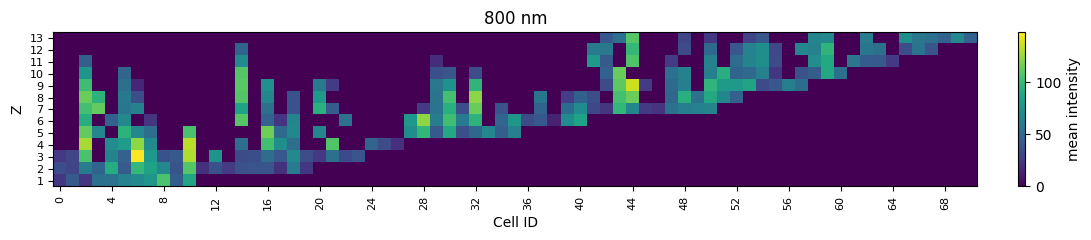

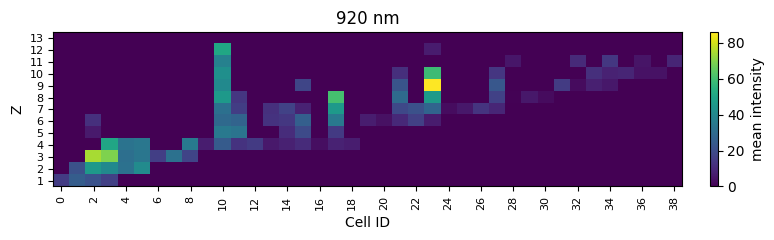

In [19]:
csv_800 = os.path.join(S5_8, "800_S5_means_bgsub.csv")
csv_920 = os.path.join(S5_9, "920_S5_means_bgsub.csv")

out_800 = os.path.join(S5_8, "800_S5_bgsub_heatmap.png")
out_920 = os.path.join(S5_9, "920_S5_bgsub_heatmap.png")

plot_bgsub_heatmap(csv_800, out_png=out_800, title="800 nm")
plot_bgsub_heatmap(csv_920, out_png=out_920, title="920 nm")


## S6 – Size ratio filtering

This step removes cell pairs whose segmented size is inconsistent between the 800 nm and 920 nm channels. Because the same cell is expected to have a similar spatial extent in both excitation conditions, large differences in mask size often indicate incorrect inter-channel matching, poor segmentation, or unstable tracking across the Z-stack.

For each mapped cell pair, the corresponding mask stacks from the two channels are indexed and compared across the full Z-stack. For each cell in each channel, the representative mask is taken from the Z-slice where that cell reaches its maximum intensity. The mask areas from the two channels are then compared using a symmetric ratio, and pairs showing excessive disagreement are excluded from further analysis.


### Visualization and controls


The interface displays the representative masks used for comparison and provides controls for adjusting the filtering threshold.
- **Blue:** mask from the 800 nm channel.  
- **Green:** mask from the 920 nm channel(Becomes **Red** if exluded)
- **Max Ratio:** maximum allowed size ratio between the two masks. Pairs exceeding this threshold are rejected.  

The interface also reports the number of accepted and rejected pairs for the selected threshold.

### Practical implementation

In practice, thresholds typically ranged between **1.5 and 2**, as small segmentation differences between channels are expected and a ratio of 1 would be overly strict. Once the threshold has been selected and the accepted pairs visually verified, press **“Save Filtered Map”** to store the filtered correspondence table. This filtered mapping is then used for the final ratiometric analysis.

In [20]:
from common_functions.data_utils import index_maskstacks
from S6_size_ratio_subtraction.size_utils import compute_area_ratios
from S6_size_ratio_subtraction.run_S6 import run_S6_size_ratio

# Build mask maps first
mask_map_800 = index_maskstacks("800",S2_8,S2_9)
mask_map_920 = index_maskstacks("920",S2_8,S2_9)

# Then run
mapping_csv = os.path.join(S4, "illumination_mapping_filtered_dual.csv")
res = compute_area_ratios(mapping_csv, mask_map_800, mask_map_920)

run_S6_size_ratio(
    res,
    mask_map_800,
    mask_map_920,
    save_path=os.path.join(S6, "area_filtered_mapping.csv")
)


## S7 – Final ratio output and pseudo-color projection

This final step computes the excitation ratio for each matched cell and generates the output files used for visualization and downstream analysis. For each accepted cell pair, the background-corrected signals from the 800 nm and 920 nm channels are combined to calculate the final ratiometric value.

In addition to the per-cell ratio table, the pipeline generates a pseudo-colored projection image in which each segmented cell is colored according to its computed ratio. This provides a direct visual summary of spatial variation in reporter activity across the field of view.

The final output includes:

- a **per-cell results table** containing the matched cell identities and their computed excitation ratios  
- a **pseudo-colored projection image** showing the ratio assigned to each cell  
- associated saved files required to reopen or reuse the final visualization state

These outputs represent the final quantitative and visual products of the analysis pipeline.

In [22]:
from S7_final_output.run_S7 import run_S7_manual_link_ratio_and_projection
pkl_file_name = "view1.pkl"

run_S7_manual_link_ratio_and_projection(
    VIEW_DIR, S2_8, S2_9, S5_8, S5_9, S6, S7,pickle_path=os.path.join(S7, pkl_file_name)
)


Loaded wide-format intensity from 800_S5_means_bgsub.csv → 71 cells, Zs 1..13
Loaded wide-format intensity from 920_S5_means_bgsub.csv → 39 cells, Zs 1..13
S7 colorbar: using RATIO_VMIN=0.2, RATIO_VMAX=0.4
